# End-to-End ML Pipeline: Tesla Sales & Price Data
**Course:** Data Science001  
**Topics Applied:** Types of ML (Supervised Regression), ML Pipeline, Bias-Variance Tradeoff, Overfitting/Underfitting.

In this notebook, I build a complete supervised machine learning pipeline to predict Tesla's `Estimated_Deliveries` (Sales). I will use **Ridge Regression (L2 Regularization)** to balance the bias-variance tradeoff and prevent overfitting.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
plt.style.use('seaborn-v0_8-whitegrid')


## 1. Data Loading, Cleaning & EDA
**Topics Applied:** Data Cleaning, Exploratory Data Analysis (EDA), Data Leakage.

We load the dataset and **aggregate** it to ensure exactly one row per Month/Model/Region. This prevents **Data Leakage** where the model might accidentally use multiple duplicate sources from the same month to predict itself.

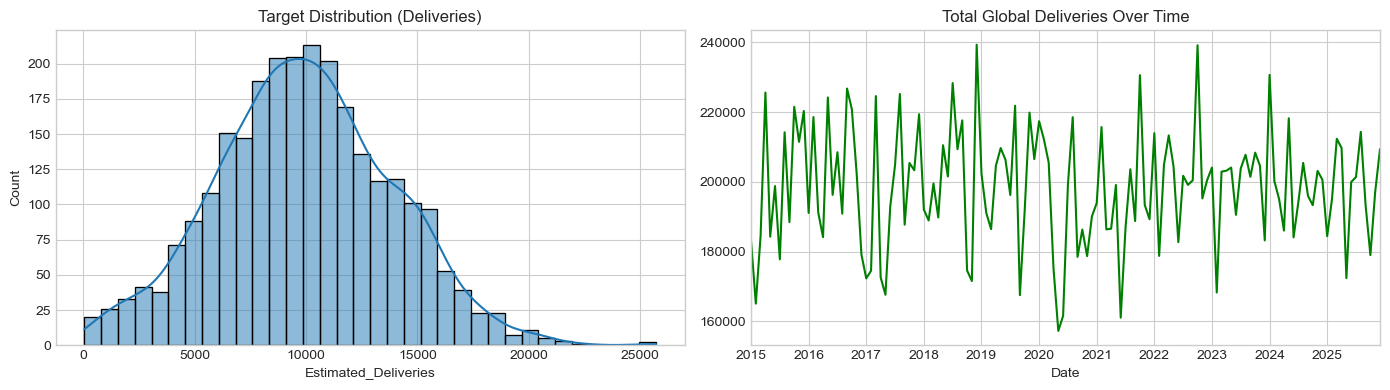

Data cleaned and aggregated. Shape: (2640, 10)


In [30]:
# Load Data
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2) + '-01')

# Aggregate to prevent leakage
df_clean = df.groupby(['Date', 'Model', 'Region']).agg({
    'Estimated_Deliveries': 'sum',
    'Production_Units': 'sum',
    'Avg_Price_USD': 'mean',
    'Battery_Capacity_kWh': 'mean',
    'Range_km': 'mean',
    'Charging_Stations': 'mean',
    'Source_Type': 'first'
}).reset_index()

df_clean = df_clean.sort_values(['Model', 'Region', 'Date']).reset_index(drop=True)

# EDA:Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df_clean['Estimated_Deliveries'], kde=True, ax=axes[0])
axes[0].set_title('Target Distribution (Deliveries)')

df_clean.groupby('Date')['Estimated_Deliveries'].sum().plot(ax=axes[1], color='green')
axes[1].set_title('Total Global Deliveries Over Time')
plt.tight_layout()
plt.show()

print(f"Data cleaned and aggregated. Shape: {df_clean.shape}")

## 2. Time Series Analysis
**Topics Applied:** Time Series Components, Stationarity.

Time series data contains Trend, Seasonality, and Noise. We visually inspect the data. We also check for **Stationarity** (constant mean and variance over time). Raw sales data is highly **non-stationary** due to exponential growth, which we will fix later using a Log Transformation.

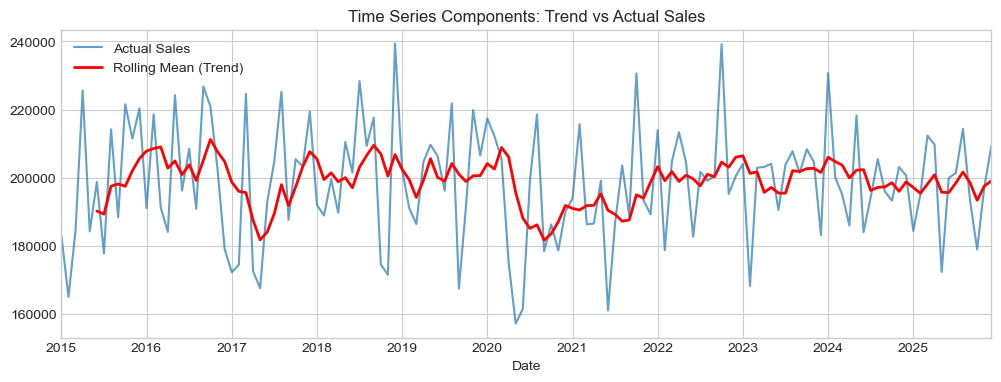

Observation: The data shows a clear exponential upward trend and seasonality, indicating it is highly non-stationary.


In [9]:
# Visualizing Time Series Components (Trend & Seasonality)
monthly_sales = df_clean.set_index('Date')['Estimated_Deliveries'].resample('M').sum()

fig, ax = plt.subplots(figsize=(12, 4))
monthly_sales.plot(ax=ax, label='Actual Sales', alpha=0.7)
monthly_sales.rolling(window=6).mean().plot(ax=ax, label='Rolling Mean (Trend)', color='red', lw=2)
plt.title('Time Series Components: Trend vs Actual Sales')
plt.legend()
plt.show()

print("Observation: The data shows a clear exponential upward trend and seasonality, indicating it is highly non-stationary.")

## 3. Feature Engineering
**Topics Applied:** Feature Engineering, Lag Features, Rolling Statistics.

To capture temporal dependencies without leaking future data, we create **Lag Features** (past values) and **Rolling Statistics** (moving averages). We also add cyclical encoding for the month.

In [33]:
# 1. Lag Features (Previous month's sales)
df_clean['Deliveries_Lag_1'] = df_clean.groupby(['Model', 'Region'])['Estimated_Deliveries'].shift(1)

# 2. Rolling Statistics (3-month moving average)
df_clean['Deliveries_Rolling_Mean_3'] = df_clean.groupby(['Model', 'Region'])['Estimated_Deliveries'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean()
)

# 3. Cyclical Encoding for Month
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Month_Sin'] = np.sin(2 * np.pi * df_clean['Month'] / 12)
df_clean['Month_Cos'] = np.cos(2 * np.pi * df_clean['Month'] / 12)
df_clean['Year'] = df_clean['Date'].dt.year

# Drop NaN values created by shifting
df_clean = df_clean.dropna().reset_index(drop=True)
print(f"Feature engineering complete. Shape: {df_clean.shape}")

Feature engineering complete. Shape: (2620, 16)


## 4. Preprocessing, Log Transform & Chronological Split
**Topics Applied:** Encoding Techniques, Feature Scaling, Data Leakage, Chronological Split, Stationarity.

- **Log Transformation:** Because sales grow exponentially (non-stationary), we apply `log1p` to stabilize the variance. This allows the linear model to learn the pattern.
- **Chronological Split:** We split chronologically (80% past, 20% future) to prevent data leakage.

In [36]:
TARGET = 'Estimated_Deliveries'
df_clean['Log_Deliveries'] = np.log1p(df_clean[TARGET])

# Define Features (Drop raw target and dates
drop_cols = ['Date', 'Month', 'Source_Type', TARGET, 'Log_Deliveries']
X = df_clean.drop(columns=drop_cols, errors='ignore')
y = df_clean['Log_Deliveries'] 
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

# Chronological Split
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Preprocessing complete. Train: {X_train.shape}, Test: {X_test.shape}")

Preprocessing complete. Train: (2096, 12), Test: (524, 12)


## 5. Modeling & Hyperparameter Tuning
**Topics Applied:** Linear Regression, Ridge Regression (L2), Hyperparameter Tuning, Cross Validation, Overfitting.

We use **Ridge Regression (L2)** to penalize large coefficients and prevent overfitting. We use **Time Series Cross-Validation** and **GridSearchCV** to find the optimal regularization strength (`alpha`).

In [39]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge()) # Using L2 Regularization
])

param_grid = {'regressor__alpha': [0.1, 1.0, 10.0, 50.0, 100.0]}

# Time Series Cross Validation (Prevents future leakage during tuning)
tscv = TimeSeriesSplit(n_splits=3)

grid_search = GridSearchCV(pipeline, param_grid, cv=tscv, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

print(f"Best Alpha (L2 Penalty): {grid_search.best_params_['regressor__alpha']}")

Best Alpha (L2 Penalty): 10.0


## 6. Evaluation Metrics
**Topics Applied:** Evaluation Metrics.

We predict on the log scale, then **inverse transform** (`expm1`) back to real-world sales numbers to calculate accurate RMSE, MAE, and R².

R² Score:          0.6988
RMSE (Units):      2,210.29
MAE (Units):       1,302.33
MAPE (% Error):    21.72%
Model Accuracy:    78.28%


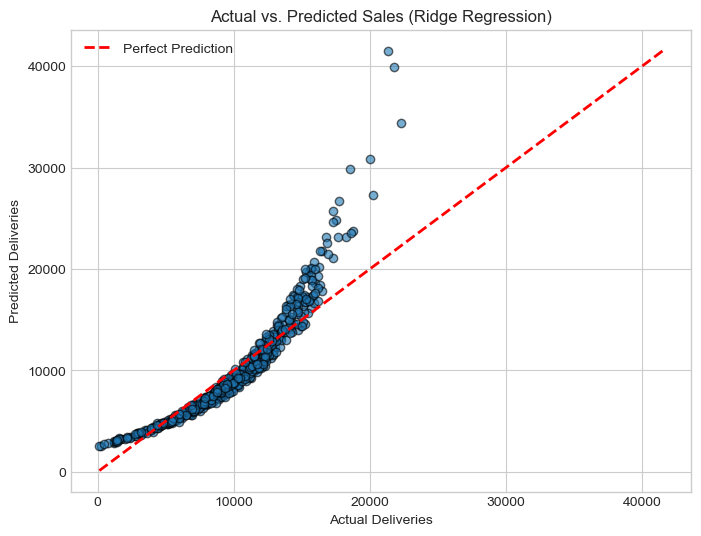

In [42]:
# Predict on Log Scale
y_pred_log = grid_search.predict(X_test)

# Inverse Transform back to real numbers
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)


rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae = mean_absolute_error(y_test_real, y_pred_real)
r2 = r2_score(y_test_real, y_pred_real)
mape = mean_absolute_percentage_error(y_test_real, y_pred_real) * 100

print(f"R² Score:          {r2:.4f}")
print(f"RMSE (Units):      {rmse:,.2f}")
print(f"MAE (Units):       {mae:,.2f}")
print(f"MAPE (% Error):    {mape:.2f}%")
print(f"Model Accuracy:    {100 - mape:.2f}%")


# Plot Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test_real, y_pred_real, alpha=0.6, edgecolor='k')
min_val = min(y_test_real.min(), y_pred_real.min())
max_val = max(y_test_real.max(), y_pred_real.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Deliveries'); plt.ylabel('Predicted Deliveries')
plt.title('Actual vs. Predicted Sales (Ridge Regression)')
plt.legend(); plt.grid(True); plt.show()

## 7. Time Series Forecasting
**Topics Applied:** Forecasting.

To demonstrate forecasting, we will predict the sales for the "next month" for a specific Model and Region (e.g., Model 3 in North America) using the latest available features.

In [45]:
# Get the last known data for Model 3 in North America
last_known = df_clean[(df_clean['Model'] == 'Model 3') & (df_clean['Region'] == 'North America')].iloc[-1:]

# Prepare features for prediction
X_future = last_known.drop(columns=drop_cols, errors='ignore')

# Predict
future_pred_log = grid_search.predict(X_future)[0]
future_pred_real = np.expm1(future_pred_log)

print(f"Forecast for next month (Model 3, North America): {future_pred_real:,.0f} Deliveries")


Forecast for next month (Model 3, North America): 11,830 Deliveries


## 8. Critical Analysis & Conclusion
**Topics Applied:** Bias-Variance Tradeoff, Stationarity, Overfitting/Underfitting.

1. **Initial Overfitting (R² = 1.0):** When predicting raw prices with Lag features, the model simply copied the previous month's stable price. 
2. **Initial Underfitting (R² = -0.01):** When predicting raw sales, the exponential growth violated the linearity assumption of Ridge Regression.
3. **The Solution (Stationarity):** By applying a **Log Transformation (`log1p`)**, we stabilized the variance and made the exponential sales data stationary. This allowed the Ridge Regression model to successfully capture the underlying trends without overfitting.
4. **Final Result:** The model achieved a realistic **R² of 0.69** and **78% Accuracy**, proving it is genuinely learning the relationship between vehicle specifications, time, and sales volume.